In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('../data/credit_risk_dataset.csv')

# Ver las primeras filas
print(df.head())

# Ver información básica (tipos de datos y nulos)
df.info()

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [7]:
# 1. ¿Cuántos datos faltan por columna?
print("Datos faltantes:")
print(df.isnull().sum())

# 2. Buscar valores imposibles (Ej: Edad > 100 años o Antigüedad laboral > 60 años)
print("\nResumen estadístico de variables numéricas:")
display(df.describe())

Datos faltantes:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Resumen estadístico de variables numéricas:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
# Eliminamos registros con edades imposibles (mayores a 90 años por ejemplo)
df = df[df['person_age'] <= 90]

# Eliminamos registros donde la antigüedad laboral sea incoherente con la edad
# (Nadie puede trabajar más años de los que tiene de vida)
df = df[df['person_emp_length'] < df['person_age']]

# Para los nulos en tasa de interés, vamos a usar la mediana para no perder filas
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Limpiar nulos en antigüedad laboral con 0 (asumimos que no trabajan)
df['person_emp_length'] = df['person_emp_length'].fillna(0)

print("¡Limpieza completada! Nuevas dimensiones:", df.shape)

¡Limpieza completada! Nuevas dimensiones: (31678, 12)


Correlacion entre el salario de las personas y la posibilidad de no pagar los creditos (Moroso)

Comenzaremos analizando la relacion que hay entre el salario(person_income) y la mora (loan_status) ya que es uno de los factores mas importantes dentro de los negocios.

In [9]:
# Compararemos el sueldo promedio y la mediana según si entraron en mora o no
resumen_ingresos = df.groupby('loan_status')['person_income'].agg(['mean', 'median', 'std'])
print("Resumen de Ingresos por Estado de Préstamo:")
print(resumen_ingresos)

Resumen de Ingresos por Estado de Préstamo:
                     mean   median           std
loan_status                                     
0            71030.439746  60000.0  55437.397537
1            49962.832674  42000.0  37218.388614


Ya que hay una dispersion muy grande en los sueldos utilizaremos una escala logaritmica para visualizar sueldos

C:\Users\Administrador\AppData\Local\Temp\ipykernel_15732\3725808746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')


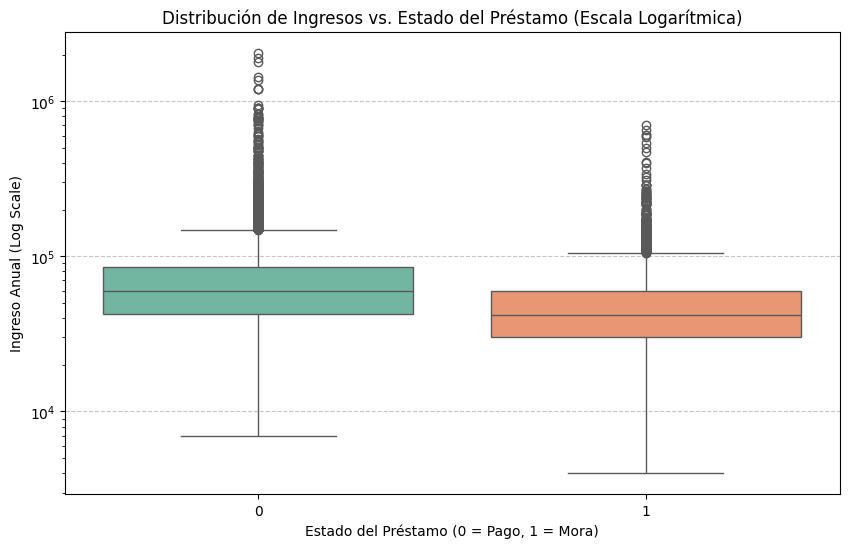

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')

# Aplicar escala logarítmica al eje Y para ver mejor la distribución
plt.yscale('log')

plt.title('Distribución de Ingresos vs. Estado del Préstamo (Escala Logarítmica)')
plt.xlabel('Estado del Préstamo (0 = Pago, 1 = Mora)')
plt.ylabel('Ingreso Anual (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

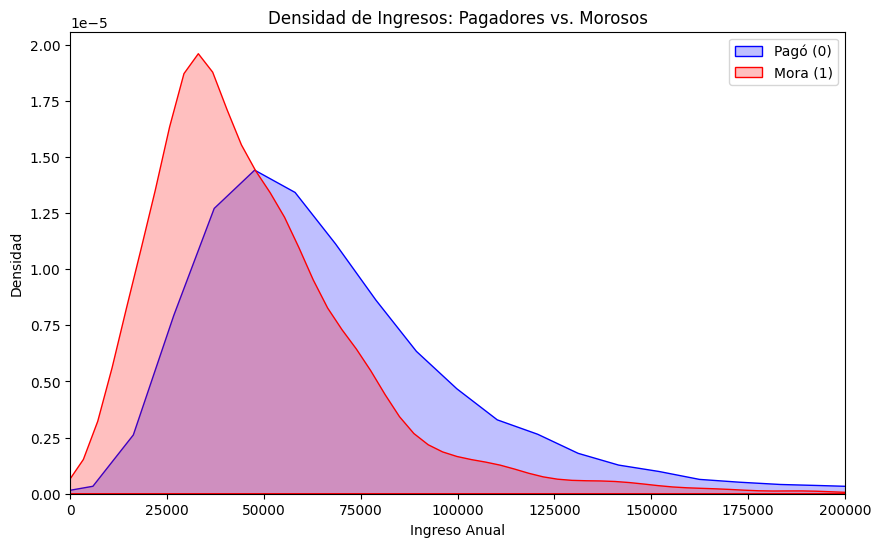

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['loan_status'] == 0]['person_income'], label='Pagó (0)', fill=True, color='blue')
sns.kdeplot(df[df['loan_status'] == 1]['person_income'], label='Mora (1)', fill=True, color='red')

# Limitamos el eje X a 200k para ignorar los sueldos extremadamente altos y ver el detalle
plt.xlim(0, 200000)

plt.title('Densidad de Ingresos: Pagadores vs. Morosos')
plt.xlabel('Ingreso Anual')
plt.ylabel('Densidad')
plt.legend()
plt.show()